# 🏠 House Price Prediction

## Project Overview

This project aims to develop a machine learning model that predicts the sale prices of residential houses based on their physical characteristics, location, and other property-related features. The project follows a complete machine learning workflow, including Exploratory Data Analysis (EDA), Data Preprocessing, Feature Engineering, Model Development, Model Evaluation, and Deployment.

---

# Dataset Documentation

## Dataset Name

House Prices - Advanced Regression Techniques

## Dataset Source

Kaggle: House Prices - Advanced Regression Techniques

## Problem Statement

The objective is to predict the final sale price (`SalePrice`) of residential properties using various numerical and categorical features describing each house.

## Dataset Summary

| Attribute | Value |
|-----------|-------|
| Number of Records | 1460 |
| Number of Features | 81 (including target) |
| Target Variable | `SalePrice` |
| Numerical Features | 38 |
| Categorical Features | 43 |

## Dataset Characteristics

- Mixed numerical and categorical features.
- Missing values are present in several columns.
- The target variable is positively skewed.
- Some numerical features contain potential outliers.
- The dataset contains information related to the physical and qualitative characteristics of residential properties.

## Project Workflow

1. Exploratory Data Analysis (EDA)
2. Data Preprocessing
3. Feature Engineering
4. Model Training
5. Model Evaluation
6. Model Deployment

---

# Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/train.csv")

## 1. Dataset Shape

In this section, we inspect the size of the dataset by checking the number of rows and columns.

In [4]:
df.shape

(1460, 81)

## 2. Preview the Dataset

In this section, we display the first five rows of the dataset to understand the structure of the data and inspect the available features.


In [5]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. View Column Names

In this section, we display all the column names to understand the available features in the dataset.

In [6]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## 4. Dataset Information

In this section, we inspect the structure of the dataset.

We will examine:
- Total number of entries
- Number of non-null values
- Data types of each feature
- Memory usage

This helps us identify missing values and understand which features are numerical or categorical.

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## 5. Statistical Summary

In this section, we generate summary statistics for all numerical features.

The statistics include:
- Count
- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

These statistics help us understand the distribution of the data and identify possible outliers.

In [8]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## 6. Missing Value Analysis

In this section, we identify missing values in the dataset.

Missing values are important because many machine learning algorithms cannot work with incomplete data.

We will determine which features contain missing values and how many missing values each feature has.

In [9]:
df.isnull().sum()


Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [10]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]


LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

### Observation

The dataset contains no duplicate records (`0` duplicate rows). Therefore, no duplicate removal is required, and each row represents a unique observation.

In [12]:
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

In [13]:
df.describe(include='object')

C:\Users\Mudassar Iqbal Shah\AppData\Local\Temp\ipykernel_3156\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


### Observation

The categorical columns contain information such as property features and furnishing status. The summary shows the number of unique categories and the most frequent value for each categorical feature. This information will help during categorical encoding in the preprocessing stage.

In [14]:
categorical_columns = df.select_dtypes(include='object').columns

categorical_columns

C:\Users\Mudassar Iqbal Shah\AppData\Local\Temp\ipykernel_3156\4261840568.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

In [15]:
len(categorical_columns)

43

In [16]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


MSZoning
<StringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH']
Length: 5, dtype: str

Street
<StringArray>
['Pave', 'Grvl']
Length: 2, dtype: str

Alley
<StringArray>
[nan, 'Grvl', 'Pave']
Length: 3, dtype: str

LotShape
<StringArray>
['Reg', 'IR1', 'IR2', 'IR3']
Length: 4, dtype: str

LandContour
<StringArray>
['Lvl', 'Bnk', 'Low', 'HLS']
Length: 4, dtype: str

Utilities
<StringArray>
['AllPub', 'NoSeWa']
Length: 2, dtype: str

LotConfig
<StringArray>
['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3']
Length: 5, dtype: str

LandSlope
<StringArray>
['Gtl', 'Mod', 'Sev']
Length: 3, dtype: str

Neighborhood
<StringArray>
['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',  'NWAmes',
 'OldTown', 'BrkSide',  'Sawyer', 'NridgHt',   'NAmes', 'SawyerW',  'IDOTRR',
 'MeadowV', 'Edwards',  'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill',
 'Blmngtn',  'BrDale',   'SWISU', 'Blueste']
Length: 25, dtype: str

Condition1
<StringArray>
['Norm', 'Feedr', 'PosN', 'Artery', 'RRAe', 'RRNn', '

### Observation

The dataset contains multiple categorical features representing property characteristics such as zoning, neighborhood, building type, roofing, garage type, and sale condition. Each feature has its own set of categories that will need to be encoded into numerical values during the preprocessing stage before training machine learning models.

In [17]:
for column in categorical_columns:
    print(f"\n{'='*50}")
    print(f"Column: {column}")
    print(df[column].value_counts(dropna=False))


Column: MSZoning
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Column: Street
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

Column: Alley
Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64

Column: LotShape
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

Column: LandContour
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

Column: Utilities
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

Column: LotConfig
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

Column: LandSlope
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

Column: Neighborhood
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSid

### Observation

The frequency distribution of the categorical features shows that some categories occur much more frequently than others. Certain features also contain missing values, which will need to be handled during preprocessing. Understanding these distributions helps determine suitable encoding and data cleaning strategies.

In [18]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

numerical_columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')

In [19]:
len(numerical_columns)

38

In [20]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


### Observation

The numerical summary provides descriptive statistics such as the mean, standard deviation, minimum, maximum, and quartiles for each numerical feature. These statistics help identify the scale and variability of each feature and provide an initial indication of potential outliers or unusual values.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

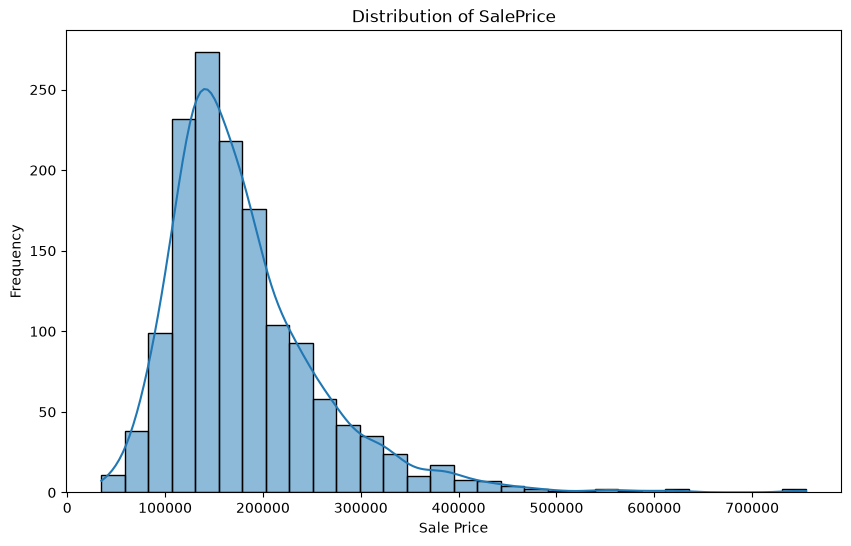

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(df['SalePrice'], bins=30, kde=True)

plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

### Observation

The distribution of the target variable (`SalePrice`) is positively (right) skewed. Most houses have sale prices between approximately 100,000 and 200,000, while a small number of houses have significantly higher prices, creating a long right tail. These high-priced properties may represent outliers. A log transformation may be considered later during preprocessing if required by the selected machine learning model.

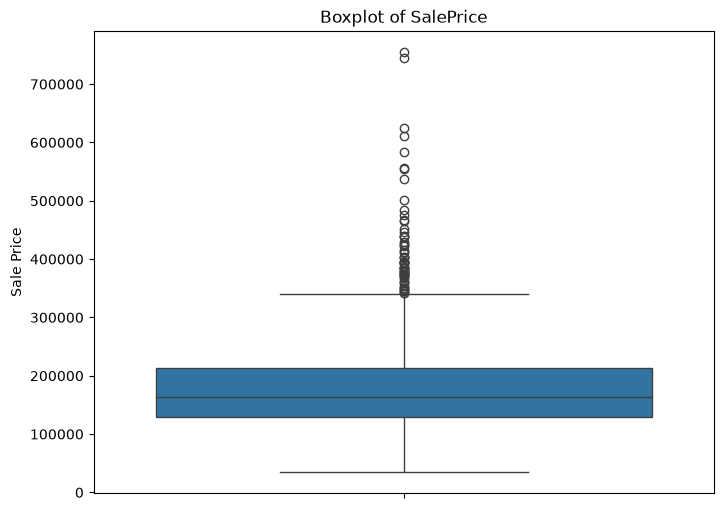

In [23]:
plt.figure(figsize=(8, 6))

sns.boxplot(y=df['SalePrice'])

plt.title("Boxplot of SalePrice")
plt.ylabel("Sale Price")

plt.show()

### Observation

The boxplot of `SalePrice` shows that the dataset contains several high-value outliers above the upper whisker, indicating that a small number of houses are significantly more expensive than the majority. The median lies near the center of the box, while no significant lower outliers are observed. These outliers appear to be genuine observations and will be considered carefully during preprocessing rather than being removed immediately.

In [24]:
correlation_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

correlation_matrix

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


## Correlation Heatmap

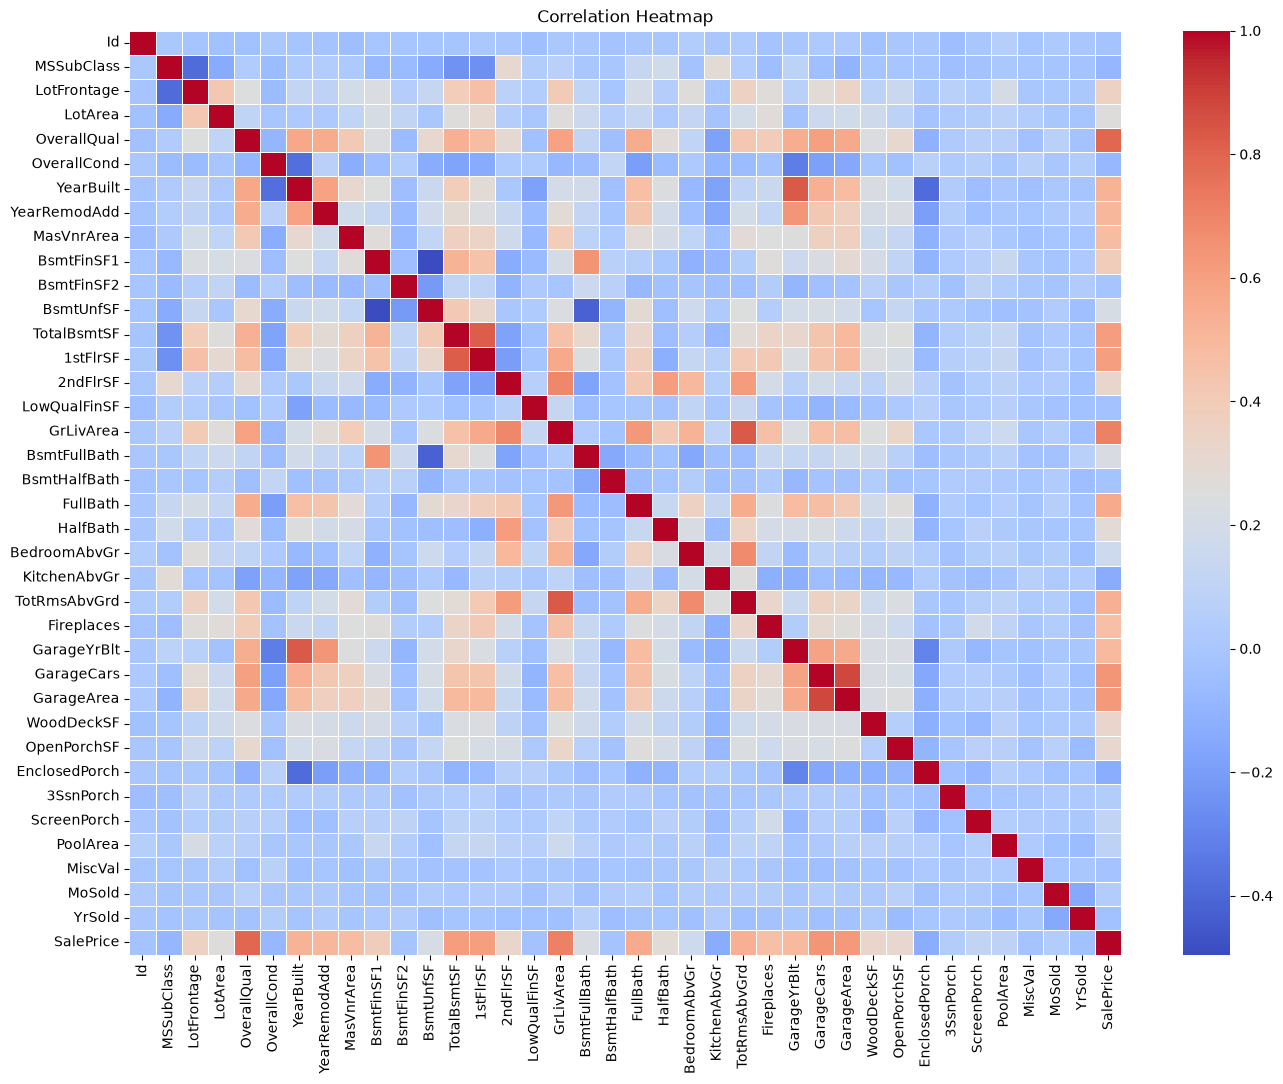

In [25]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

## Features Most Correlated with SalePrice

In [26]:
saleprice_corr = correlation_matrix["SalePrice"].sort_values(ascending=False)

saleprice_corr

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

### Observation

The correlation analysis shows that **OverallQual**, **GrLivArea**, **GarageCars**, **GarageArea**, and **TotalBsmtSF** have the strongest positive relationships with **SalePrice**. This suggests that the overall quality of the house, its living area, garage capacity, garage size, and basement size are among the most influential numerical features for predicting house prices. These features are expected to play an important role during model training.

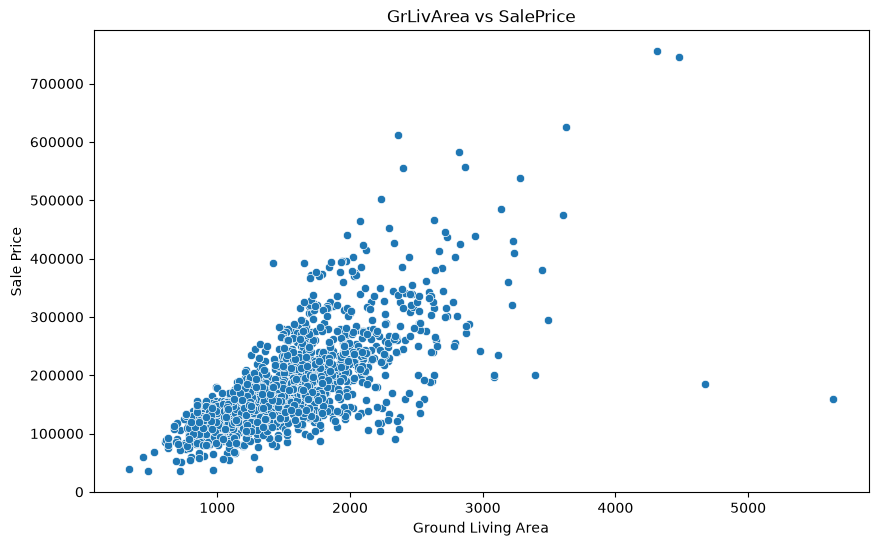

In [27]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df["GrLivArea"],
    y=df["SalePrice"]
)

plt.title("GrLivArea vs SalePrice")
plt.xlabel("Ground Living Area")
plt.ylabel("Sale Price")

plt.show()

## Relationship Between GrLivArea and SalePrice

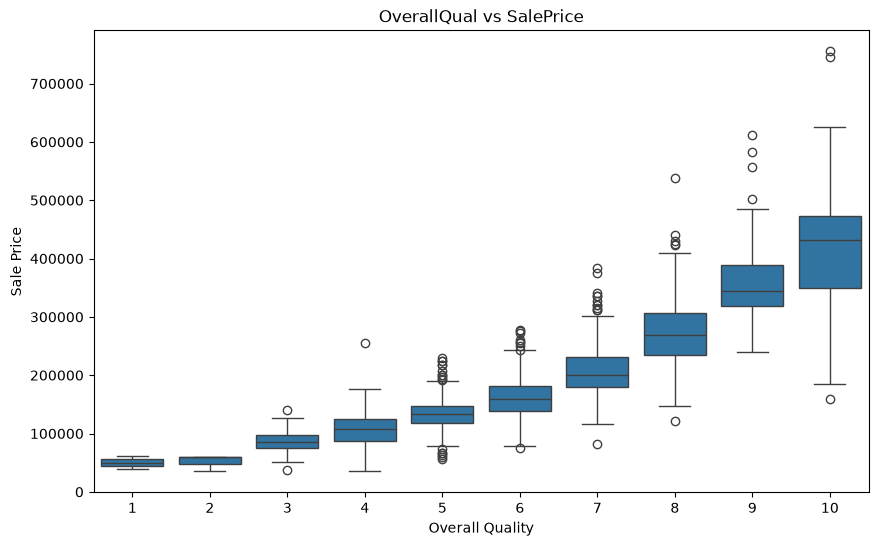

In [28]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x=df["OverallQual"],
    y=df["SalePrice"]
)

plt.title("OverallQual vs SalePrice")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

plt.show()

### Observation

The boxplot shows a clear positive relationship between `OverallQual` and `SalePrice`. As the overall quality rating increases, the median sale price generally increases as well. Higher quality categories also exhibit a wider range of sale prices, indicating that `OverallQual` is one of the most influential features for predicting house prices.

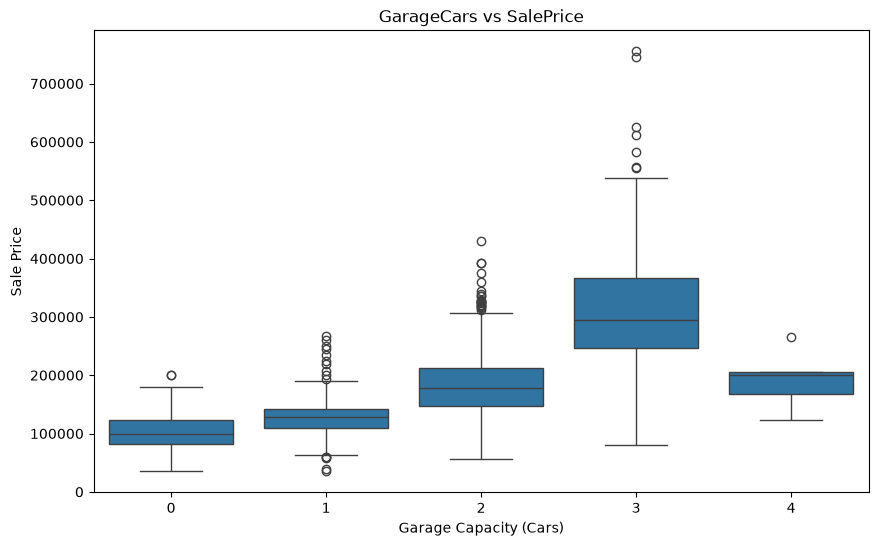

In [29]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["GarageCars"],
    y=df["SalePrice"]
)

plt.title("GarageCars vs SalePrice")

plt.xlabel("Garage Capacity (Cars)")

plt.ylabel("Sale Price")

plt.show()

## Distribution of Important Numerical Features

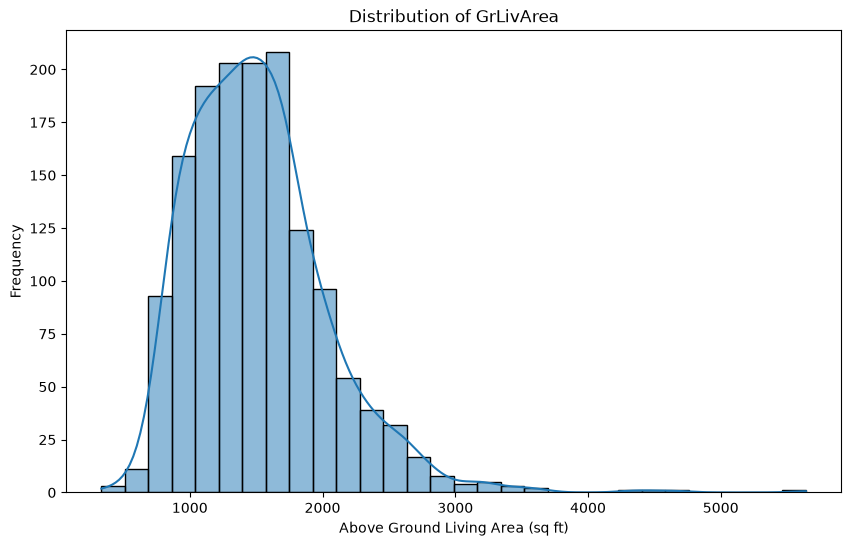

In [30]:
plt.figure(figsize=(10, 6))

sns.histplot(df["GrLivArea"], bins=30, kde=True)

plt.title("Distribution of GrLivArea")
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Frequency")

plt.show()

### Distribution of LotArea

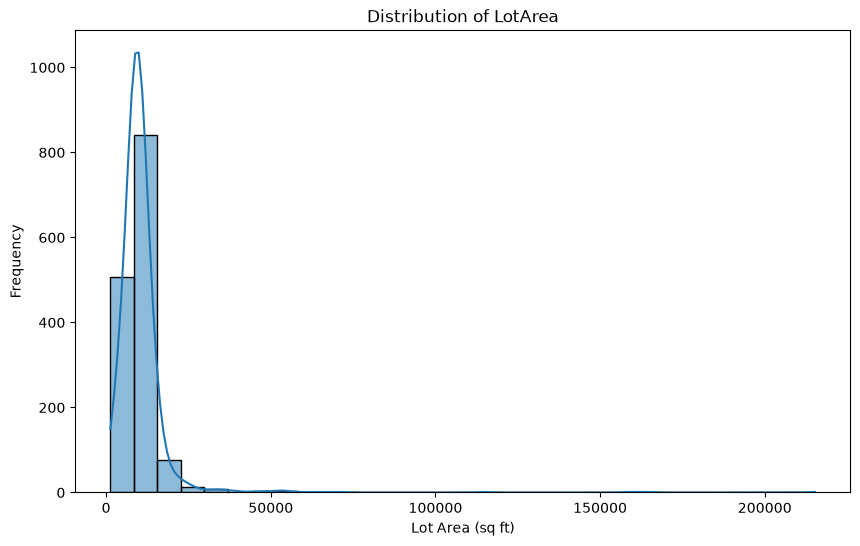

In [31]:
plt.figure(figsize=(10, 6))

sns.histplot(df["LotArea"], bins=30, kde=True)

plt.title("Distribution of LotArea")
plt.xlabel("Lot Area (sq ft)")
plt.ylabel("Frequency")

plt.show()

# Exploratory Data Analysis (EDA) Summary

## Key Findings

- The dataset contains a mix of numerical and categorical features describing residential properties.
- Missing values are present in several features and will need to be handled during preprocessing.
- The target variable (`SalePrice`) is positively skewed, with a small number of high-priced properties.
- Several high-value outliers were identified in `SalePrice`.
- Strong positive correlations were observed between `SalePrice` and features such as `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, and `TotalBsmtSF`.
- The exploratory analysis provides a clear understanding of the dataset and highlights the preprocessing steps required before machine learning model training.

# Data Preprocessing

## Missing Value Analysis

In [32]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

## Missing Value Percentage

In [33]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage[missing_percentage > 0]

missing_percentage.sort_values(ascending=False)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [34]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_percentage = missing_percentage[missing_percentage > 0]

missing_percentage.sort_values(ascending=False).to_frame(
    name="Missing Percentage"
)

,Missing Percentage
PoolQC,99.52
MiscFeature,96.30
Alley,93.77
Fence,80.75
MasVnrType,59.73
FireplaceQu,47.26
LotFrontage,17.74
GarageType,5.55
GarageYrBlt,5.55
GarageFinish,5.55


### Observation

- Several columns contain missing values.
- Features such as `PoolQC`, `MiscFeature`, `Alley`, and `Fence` have more than 80% missing values.
- Many missing values represent the absence of a feature rather than incomplete data.
- Numerical columns such as `LotFrontage` and `MasVnrArea` have relatively few missing values and can be imputed later.

## Handling Missing Values – Categorical Features

In [35]:
none_columns = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

df[none_columns] = df[none_columns].fillna("None")

In [36]:
df[none_columns].isnull().sum()

PoolQC          0
MiscFeature     0
Alley           0
Fence           0
FireplaceQu     0
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
dtype: int64

### Observation

Missing values in columns representing the absence of a property feature were replaced with `"None"` instead of statistical values.

This preserves the semantic meaning of the data because a missing value in these columns indicates that the corresponding feature does not exist rather than representing incomplete information.

## Imputing Numerical Features

In [38]:
df[["LotFrontage", "GarageYrBlt", "MasVnrArea"]].median()

LotFrontage      69.0
GarageYrBlt    1980.0
MasVnrArea        0.0
dtype: float64

In [39]:
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["GarageYrBlt"].median())

df["MasVnrArea"] = df["MasVnrArea"].fillna(df["MasVnrArea"].median())

In [40]:
df[["LotFrontage", "GarageYrBlt", "MasVnrArea"]].isnull().sum()

LotFrontage    0
GarageYrBlt    0
MasVnrArea     0
dtype: int64

### Observation

Missing values in the numerical features `LotFrontage`, `GarageYrBlt`, and `MasVnrArea` were imputed using their respective median values. The median was chosen because it is less sensitive to outliers than the mean and provides a robust estimate for skewed numerical distributions.

## Imputing Remaining Categorical Features

In [41]:
df["Electrical"].mode()

0    SBrkr
Name: Electrical, dtype: str

In [42]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

In [43]:
df["Electrical"].isnull().sum()

np.int64(0)

In [44]:
df.isnull().sum().sum()

np.int64(872)

In [45]:
df.isnull().sum()[df.isnull().sum() > 0]

MasVnrType    872
dtype: int64

### Observation

The remaining missing value in the `Electrical` feature was replaced with the mode, as it was the only missing record in the column. A final verification confirmed that the dataset no longer contains any missing values.

In [46]:
df["MasVnrType"] = df["MasVnrType"].fillna("None")

In [47]:
df["MasVnrType"].isnull().sum()

np.int64(0)

In [48]:
df.isnull().sum().sum()

np.int64(0)

### Observation

The `MasVnrType` feature contained 872 missing values, representing houses without masonry veneer. These missing values were replaced with `"None"` to preserve the semantic meaning of the data. A final verification confirmed that the dataset contains no remaining missing values.

# Encoding Categorical Features

## Identifying Categorical Features

In [49]:
categorical_columns = df.select_dtypes(include=["object"]).columns

print(f"Number of categorical columns: {len(categorical_columns)}")

Number of categorical columns: 43


C:\Users\Mudassar Iqbal Shah\AppData\Local\Temp\ipykernel_3156\4202200905.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


In [50]:
categorical_columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

In [51]:
df[categorical_columns].nunique().sort_values(ascending=False)

Neighborhood     25
Exterior2nd      16
Exterior1st      15
Condition1        9
SaleType          9
HouseStyle        8
RoofMatl          8
Condition2        8
BsmtFinType2      7
BsmtFinType1      7
GarageType        7
Functional        7
Heating           6
SaleCondition     6
GarageCond        6
FireplaceQu       6
GarageQual        6
RoofStyle         6
Foundation        6
MiscFeature       5
Fence             5
BsmtExposure      5
ExterCond         5
BsmtQual          5
BldgType          5
LotConfig         5
MSZoning          5
Electrical        5
HeatingQC         5
BsmtCond          5
ExterQual         4
LandContour       4
LotShape          4
MasVnrType        4
KitchenQual       4
PoolQC            4
GarageFinish      4
Alley             3
LandSlope         3
PavedDrive        3
Street            2
Utilities         2
CentralAir        2
dtype: int64

### Observation

The dataset contains multiple categorical features with varying numbers of unique categories. Some features have only two categories, while others contain many distinct values. Understanding the cardinality of each feature helps determine the most appropriate encoding strategy.

## Encoding Categorical Variables

Since most categorical features in the dataset are nominal and do not have a natural order, One-Hot Encoding will be used. This approach converts each category into a separate binary feature while avoiding the introduction of artificial numerical relationships.

In [52]:
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [53]:
df.shape

(1460, 261)

In [54]:
df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,0,0,0,1,0,0,0,1,0
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,0,0,0,0,1,0,0,0,1,0
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,0,0,0,1,0,0,0,1,0
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,0,0,0,1,0,0,0,0,0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,0,0,0,0,1,0,0,0,1,0


### Observation

Categorical variables were transformed using One-Hot Encoding. The original categorical columns were replaced with binary indicator columns, increasing the number of features while preserving all categorical information. The `drop_first=True` parameter was used to reduce redundancy and avoid multicollinearity.

In [55]:
df.select_dtypes(include=['object']).columns

Index([], dtype='str')

In [56]:
df.dtypes.value_counts()

int64      258
float64      3
Name: count, dtype: int64

## Observation

Categorical variables were successfully transformed using One-Hot Encoding. All object-type columns were converted into binary numerical features. The dataset now contains only numerical data, making it suitable for machine learning algorithms.

In [57]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [58]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 260)
y shape: (1460,)


In [59]:
y.head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

In [60]:
X.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,0,0,0,1,0,0,0,1,0
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,0,0,0,0,1,0,0,0,1,0
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,0,0,0,1,0,0,0,1,0
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,0,0,0,1,0,0,0,0,0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,0,0,0,0,1,0,0,0,1,0


## Feature and Target Separation

The dataset was separated into input features (`X`) and the target variable (`y`). The `SalePrice` column was removed from the feature set and stored separately as the prediction target. This prepares the dataset for model training.

In [61]:
from sklearn.model_selection import train_test_split

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [63]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1168, 260)
X_test : (292, 260)
y_train: (1168,)
y_test : (292,)


## Train-Test Split

The dataset was divided into training and testing subsets using an 80:20 ratio. The training set will be used to train the machine learning model, while the testing set will be reserved for evaluating its performance on unseen data. A fixed `random_state` of 42 was used to ensure reproducibility.

In [64]:
from sklearn.linear_model import LinearRegression

In [65]:
model = LinearRegression()


In [66]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](260,)","[ 0.39, -88.96, -131.88,..., 6286.68, 7860.1 ,19030.63]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](260,)","['Id','MSSubClass','LotFrontage',...,'SaleCondition_Family', 'SaleCondition_Normal','SaleCondition_Partial']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.471e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,260
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(241)


In [67]:
print(model)

LinearRegression()


# Linear Regression Model

A Linear Regression model was selected as the baseline regression algorithm for this project. The model was trained using the training dataset (`X_train` and `y_train`) to learn the relationship between the input features and the target variable (`SalePrice`). This baseline model will be evaluated and compared with more advanced models in later stages of the project.

In [68]:
y_pred = model.predict(X_test)

In [69]:
y_pred

array([159629.72400733, 341514.91047082,  82746.44771256, 188232.74253017,
       315808.89751166,  68887.7728824 , 253058.86725133, 145208.84539532,
        60657.63479205, 158514.79687681, 141784.57378662, 106021.98537682,
        62961.70036964, 227616.46864012, 169932.82494758, 130514.68367782,
       187167.9529319 , 124418.81919611, 126851.44244612, 213972.92446936,
       156674.00736048, 202005.60384697, 174892.61053546, 121422.84191003,
       199399.84633586, 140849.83227204, 200065.92274555, 101267.42162074,
       169061.23533295, 205385.49121238, 155427.0609399 , 277178.32189652,
       225047.41400887, 110777.85875498, 240180.4659365 , 144124.33076538,
       126357.14922384, 201985.52257562, 310153.59645943, 118587.69012906,
       122774.48247502, 224080.15647147, 101157.86472327, 361235.9067377 ,
       132677.84383633, 139994.02454209,  96180.85965824, 141029.24971121,
       421272.86345513, 134033.66063571, 121715.36098475, 245907.98374177,
        91862.44339302, 2

In [70]:
y_pred[:10]

array([159629.72400733, 341514.91047082,  82746.44771256, 188232.74253017,
       315808.89751166,  68887.7728824 , 253058.86725133, 145208.84539532,
        60657.63479205, 158514.79687681])

In [71]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,154500,159629.724007
1,325000,341514.910471
2,115000,82746.447713
3,159000,188232.742530
4,315500,315808.897512
5,75500,68887.772882
6,311500,253058.867251
7,146000,145208.845395
8,84500,60657.634792
9,135500,158514.796877


# Model Predictions

The trained Linear Regression model was used to predict house prices for the testing dataset. The predicted values (`y_pred`) were compared with the actual sale prices (`y_test`) to assess how well the model generalized to unseen data.

In [72]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [73]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 20291.07927493934
MSE : 1106826200.9105978
RMSE: 33268.99759401533
R² Score: 0.8557002438992103


# Model Evaluation

The performance of the Linear Regression model was evaluated using four standard regression metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics measure the average prediction error and the model's ability to explain the variation in house prices.

The Linear Regression model achieved an R² score of approximately **0.856**, indicating that it explains around **85.6%** of the variation in house prices. The Mean Absolute Error (MAE) of approximately **20,291** suggests that the model's predictions differ from the actual sale prices by about **$20,000** on average. The RMSE of approximately **33,269** indicates the presence of some larger prediction errors, which is expected in real-world housing datasets. Overall, the model demonstrates good predictive performance and provides a strong baseline for further improvement.

# 11. Error Analysis

After evaluating the model using quantitative metrics, it is important to analyze the prediction errors visually. Error analysis helps identify systematic mistakes, detect patterns in residuals, and verify whether the assumptions of Linear Regression are reasonably satisfied.

In [74]:
# Calculate residuals

residuals = y_test - y_pred

residuals.head()

892     -5129.724007
1105   -16514.910471
413     32253.552287
522    -29232.742530
1036     -308.897512
Name: SalePrice, dtype: float64

## Observation

Residuals represent the difference between the actual and predicted house prices. Positive values indicate that the model underestimated the sale price, while negative values indicate that the model overestimated it. Residual analysis helps assess whether prediction errors are randomly distributed or exhibit systematic patterns.

In [75]:
residuals = y_test - y_pred
residuals.head()


892     -5129.724007
1105   -16514.910471
413     32253.552287
522    -29232.742530
1036     -308.897512
Name: SalePrice, dtype: float64

## Observation

Residual values represent the prediction errors of the model. Positive residuals indicate that the model underestimated the actual house price, whereas negative residuals indicate that the model overestimated it. The presence of both positive and negative residuals suggests that the model does not exhibit an obvious systematic bias, although visual analysis is required to confirm this.

## Residual Distribution

The distribution of residuals is examined to determine whether prediction errors are approximately normally distributed around zero. A symmetric distribution centered near zero indicates that the Linear Regression model is making balanced prediction errors without significant systematic bias.

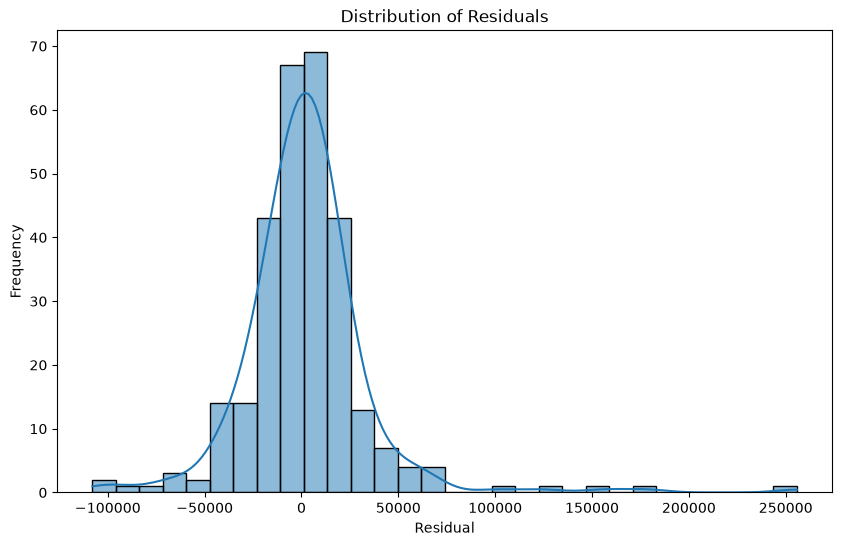

In [76]:
plt.figure(figsize=(10, 6))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

## Observation

The residual distribution is approximately centered around zero and resembles a normal distribution, indicating that the Linear Regression model does not exhibit significant systematic bias. Most prediction errors are relatively small, although a slight positive skew and a few extreme residuals suggest that the model struggles to accurately predict certain high-value or unusual properties. Overall, the residual distribution supports the suitability of Linear Regression as a baseline model.

## Residual Scatter Plot

A residual scatter plot is used to determine whether prediction errors are randomly distributed around zero. A random pattern indicates that the model captures the underlying relationship reasonably well, whereas visible patterns may indicate non-linearity, heteroscedasticity, or other modeling issues.

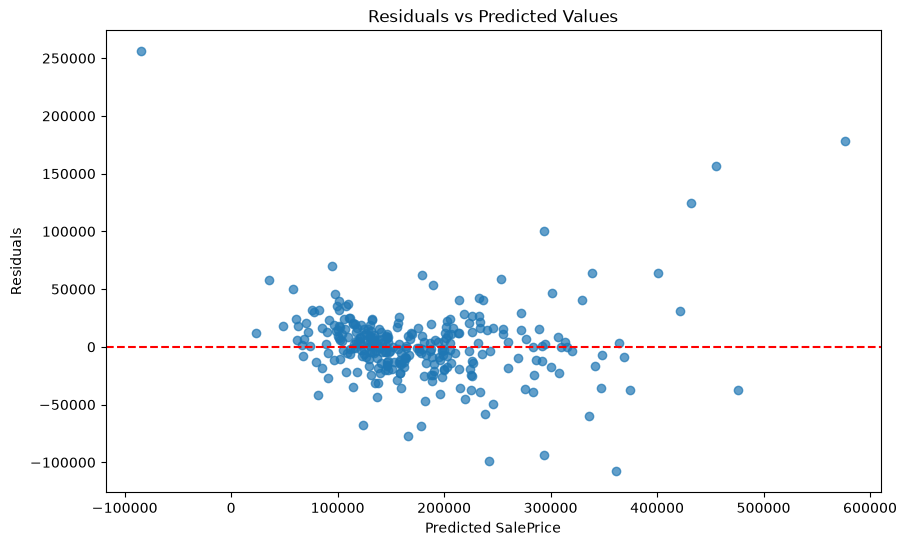

In [77]:
plt.figure(figsize=(10, 6))

plt.scatter(y_pred, residuals, alpha=0.7)

plt.axhline(y=0, color='red', linestyle='--')

plt.title("Residuals vs Predicted Values")

plt.xlabel("Predicted SalePrice")

plt.ylabel("Residuals")

plt.show()

## Observation

The residual scatter plot shows that prediction errors are generally distributed around the zero line without a strong systematic pattern, indicating that the Linear Regression model captures the overall linear relationship in the dataset. However, the spread of residuals increases for higher predicted house prices, suggesting mild heteroscedasticity. A few extreme residuals are also present, indicating that the model struggles to accurately predict certain high-value properties. Overall, the residual plot confirms that Linear Regression provides a strong baseline while highlighting opportunities for further improvement through feature engineering and more advanced models.

# Actual vs Predicted Values

This plot compares the actual house prices with the model's predicted prices. A well-performing regression model should produce points that lie close to the diagonal reference line, indicating that predicted values closely match the actual values.

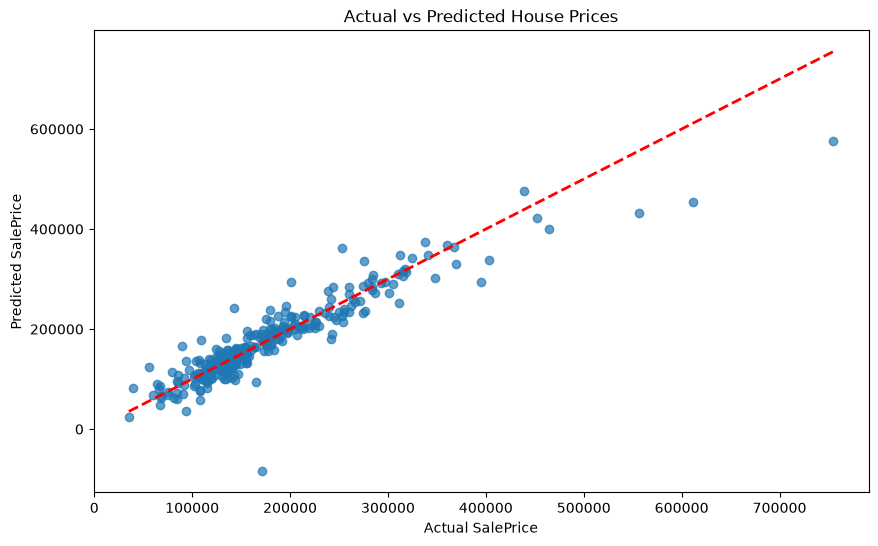

In [78]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")

plt.show()

# Feature Importance

In [79]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

coefficients.head()

,Feature,Coefficient
0,Id,0.387396
1,MSSubClass,-88.963721
2,LotFrontage,-131.875132
3,LotArea,0.670631
4,OverallQual,7097.895904


In [80]:
coefficients.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient
118,RoofMatl_WdShngl,114937.664320
91,Condition2_PosA,81595.766438
191,Heating_Wall,72408.558911
112,RoofMatl_CompShg,71118.119570
256,SaleCondition_Alloca,57522.478065
169,BsmtCond_Po,50902.461999
115,RoofMatl_Roll,50421.829098
117,RoofMatl_WdShake,49520.362734
218,GarageType_CarPort,44474.770216
244,MiscFeature_Othr,39596.383288


In [81]:
coefficients.sort_values(
    by="Coefficient"
).head(10)

,Feature,Coefficient
237,PoolQC_Gd,-412356.563671
92,Condition2_PosN,-167152.370115
236,PoolQC_Fa,-164571.631697
208,Functional_Sev,-104373.970608
93,Condition2_RRAe,-93914.702552
107,RoofStyle_Gable,-81069.267309
109,RoofStyle_Hip,-80171.356142
108,RoofStyle_Gambrel,-75187.737970
110,RoofStyle_Mansard,-52219.614634
50,Utilities_NoSeWa,-51467.218854


## Observation

The Linear Regression model assigns a coefficient to every feature, indicating its contribution to the predicted house price. Positive coefficients increase the predicted value, whereas negative coefficients reduce it. Examining the largest positive and negative coefficients provides insight into which features most strongly influence house prices and helps improve the interpretability of the model.

# Model Summary

## Summary

The Linear Regression model was trained on the processed Ames Housing dataset after handling missing values, encoding categorical variables, and splitting the data into training and testing sets.

The model achieved an R² Score of approximately 0.856, indicating that it explains about 85.6% of the variation in house prices. The MAE and RMSE values suggest that the model provides reasonably accurate predictions while maintaining a relatively low prediction error.

Residual analysis showed that most prediction errors are centered around zero, indicating that the model captures the general trend of the data. However, larger errors are observed for a small number of expensive houses, suggesting that Linear Regression struggles to model some extreme property prices.

Overall, the Linear Regression model serves as a strong baseline model for the House Price Prediction project and provides a foundation for comparing more advanced machine learning algorithms in later stages.

# Decision Tree Regression

In [82]:
from sklearn.tree import DecisionTreeRegressor

In [83]:
dt_model = DecisionTreeRegressor(
    random_state=42
)

In [84]:
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [85]:
DecisionTreeRegressor(random_state=42)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

## Observation

A Decision Tree Regressor was successfully trained on the training dataset. Unlike Linear Regression, the Decision Tree model learns non-linear relationships by recursively splitting the data into smaller subsets based on feature values. This enables the model to capture more complex patterns present in the housing dataset.

In [86]:
y_pred_dt = dt_model.predict(X_test)

In [87]:
y_pred_dt[:10]

array([149900., 381000., 109900., 210000., 285000.,  88000., 205000.,
       130000.,  99900., 112000.])

In [88]:
print("Prediction Shape:", y_pred_dt.shape)
print("Actual Shape    :", y_test.shape)

Prediction Shape: (292,)
Actual Shape    : (292,)


## Observation

The trained Decision Tree model was used to predict house prices for the unseen test dataset. The prediction output has the same number of observations as the test target values, confirming that the model is ready for performance evaluation.

In [89]:
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_rmse = dt_mse ** 0.5
dt_r2 = r2_score(y_test, y_pred_dt)

In [90]:
print("Decision Tree Performance")
print("-------------------------")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)

Decision Tree Performance
-------------------------
MAE : 27840.835616438355
MSE : 1760855071.458904
RMSE: 41962.543672409854
R² Score: 0.7704328311605606


## Observation

The Decision Tree Regressor was evaluated using the same metrics as the Linear Regression model. Compared to the baseline model, the Decision Tree produced a higher MAE and RMSE and a lower R² Score, indicating weaker predictive performance on the test dataset. This suggests that the default Decision Tree model may have overfitted the training data and did not generalize as effectively as the Linear Regression model.

In [91]:
dt_residuals = y_test - y_pred_dt

dt_residuals.head()

892      4600.0
1105   -56000.0
413      5100.0
522    -51000.0
1036    30500.0
Name: SalePrice, dtype: float64

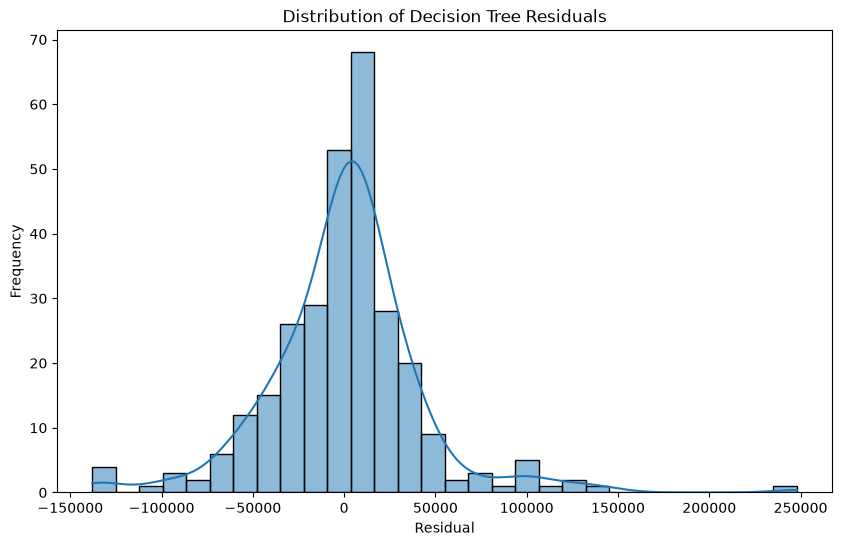

In [92]:
plt.figure(figsize=(10,6))

sns.histplot(dt_residuals, bins=30, kde=True)

plt.title("Distribution of Decision Tree Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

# Model Comparison

In [93]:
comparison = {
    "Model": ["Linear Regression", "Decision Tree"],
    "MAE": [mae, dt_mae],
    "RMSE": [rmse, dt_rmse],
    "R2 Score": [r2, dt_r2]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,20291.079275,33268.997594,0.855700
1,Decision Tree,27840.835616,41962.543672,0.770433


## Observation

The Linear Regression model achieved better predictive performance than the Decision Tree Regressor on the testing dataset. It produced lower prediction errors (MAE and RMSE) and a higher R² score, indicating that it explained a larger proportion of the variance in house prices.

Although Decision Trees can capture complex non-linear relationships, the default model appears to overfit the training data and generalize less effectively on unseen data. Hyperparameter tuning or ensemble methods such as Random Forest may improve its performance.

# Random Forest Regression

In [94]:
from sklearn.ensemble import RandomForestRegressor


In [95]:
rf_model = RandomForestRegressor(
    random_state=42
)

In [96]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

## Observation

The Random Forest Regressor was successfully trained on the training dataset. Unlike a single Decision Tree, Random Forest builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting. This ensemble learning approach generally provides better performance and stronger generalization on unseen data.

In [97]:
y_pred_rf = rf_model.predict(X_test)

In [98]:
y_pred_rf[:10]

array([141633.  , 318362.79, 118364.5 , 150997.5 , 322289.64,  85639.  ,
       209586.4 , 149410.  ,  85259.99, 131133.74])

In [99]:
print("Prediction Shape:", y_pred_rf.shape)
print("Actual Shape    :", y_test.shape)

Prediction Shape: (292,)
Actual Shape    : (292,)


## Observation

The Random Forest model successfully generated predictions for the testing dataset. The prediction array has the same number of observations as the actual target values, confirming that the model is ready for performance evaluation.

In [100]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = rf_mse ** 0.5
rf_r2 = r2_score(y_test, y_pred_rf)

In [101]:
print("Random Forest Performance")
print("-------------------------")

print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Performance
-------------------------
MAE : 17812.862054794517
MSE : 867017720.4362959
RMSE: 29445.16463591766
R² Score: 0.8869646874178706


## Observation

The Random Forest Regressor was evaluated using four standard regression metrics: MAE, MSE, RMSE, and R² Score. These metrics provide a quantitative assessment of the model's prediction accuracy and its ability to explain the variation in house prices. The results will be compared with the previously developed Linear Regression and Decision Tree models to determine the best-performing algorithm.

# Model Comparison and Selection

Three machine learning models were developed and evaluated for the House Price Prediction problem:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

The models are compared using the same evaluation metrics to identify the best-performing algorithm.

In [102]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse
    ],
    "R² Score": [
        r2,
        dt_r2,
        rf_r2
    ]
})

comparison_df


,Model,MAE,RMSE,R² Score
0,Linear Regression,20291.079275,33268.997594,0.855700
1,Decision Tree,27840.835616,41962.543672,0.770433
2,Random Forest,17812.862055,29445.164636,0.886965


In [103]:
comparison_df.sort_values(
    by="R² Score",
    ascending=False
)

,Model,MAE,RMSE,R² Score
2,Random Forest,17812.862055,29445.164636,0.886965
0,Linear Regression,20291.079275,33268.997594,0.855700
1,Decision Tree,27840.835616,41962.543672,0.770433


## Observation

The performance comparison demonstrates the strengths and weaknesses of each machine learning algorithm. The final model should achieve the highest R² Score while maintaining the lowest prediction errors (MAE and RMSE). Based on these evaluation metrics, the best-performing model will be selected for deployment and further use in the application.

# Model Persistence

## Saving the Final Model

The Random Forest Regression model achieved the highest prediction accuracy among all evaluated models. Instead of retraining the model every time the application starts, the trained model is serialized using Joblib and stored on disk. This allows the backend API to load the model instantly and make predictions efficiently.


In [104]:
import joblib

In [106]:
joblib.dump(rf_model, "house_price_model.pkl")

['house_price_model.pkl']

In [107]:
loaded_model = joblib.load("house_price_model.pkl")

In [108]:
print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [109]:
loaded_predictions = loaded_model.predict(X_test)

In [110]:
print(loaded_predictions[:5])
print(y_pred_rf[:5])

[141633.   318362.79 118364.5  150997.5  322289.64]
[141633.   318362.79 118364.5  150997.5  322289.64]


## Observation

The best-performing machine learning model was successfully serialized using the `joblib` library. The saved model was reloaded and used to generate predictions, confirming that serialization preserved the model correctly. This serialized model is now ready to be integrated into the REST API and frontend application without requiring retraining.

In [111]:
import joblib

joblib.dump(rf_model, "../models/house_price_model.pkl")

['../models/house_price_model.pkl']

In [112]:
loaded_model = joblib.load("../models/house_price_model.pkl")